In [9]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install shap transformers --quiet

print("Libraries installed successfully")

Libraries installed successfully


In [1]:
import pandas as pd
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Check GPU
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [11]:
model_path = "/content/drive/MyDrive/FactLens_Group9/data/distilbert_model"

tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded successfully")
print(f"Running on: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully
Running on: cuda


In [12]:
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_cleaned.csv")

# Sample 5 fake and 5 real articles
fake_samples = df[df["label"] == "FAKE"].sample(5, random_state=42)
real_samples = df[df["label"] == "REAL"].sample(5, random_state=42)
samples = pd.concat([fake_samples, real_samples]).reset_index(drop=True)

print(f"Dataset loaded: {len(df)} articles")
print(f"Sample articles: {len(samples)} — 5 Fake, 5 Real")

Dataset loaded: 38590 articles
Sample articles: 10 — 5 Fake, 5 Real


In [13]:
def predict_for_shap(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

# Test it
test = predict_for_shap(["This is a test"])
print(f"Prediction function working")
print(f"FAKE probability: {test[0][0]:.4f}")
print(f"REAL probability: {test[0][1]:.4f}")

Prediction function working
FAKE probability: 0.9998
REAL probability: 0.0002


In [18]:
!pip install captum --quiet

from captum.attr import LayerIntegratedGradients
import torch

print("Captum loaded successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 176.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ope

In [19]:
def get_integrated_gradients(text, label=0):
    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    # Get embeddings
    embeddings = model.distilbert.embeddings(input_ids)

    # Define forward function
    def forward_func(embeddings, attention_mask):
        outputs = model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask
        )
        return torch.softmax(outputs.logits, dim=1)[:, label]

    # Baseline — all zeros
    baseline = torch.zeros_like(embeddings)

    # Run integrated gradients
    lig = LayerIntegratedGradients(
        forward_func,
        model.distilbert.embeddings
    )

    attributions, delta = lig.attribute(
        embeddings,
        baseline,
        additional_forward_args=(attention_mask,),
        return_convergence_delta=True,
        n_steps=50
    )

    # Sum across embedding dimension
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)

    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Create word score pairs - filter special tokens
    word_scores = []
    for token, score in zip(tokens, attributions.cpu().detach().numpy()):
        if token not in ["[CLS]", "[SEP]", "[PAD]"]:
            word_scores.append((token, float(score)))

    return word_scores

print("Integrated gradients function defined")

Integrated gradients function defined


In [17]:
# Debug - check raw SHAP values
print("Raw SHAP values shape:", shap_values_fake.values.shape)
print("Sample raw values:", shap_values_fake[0, :, 0].values[:10])
print("Max value:", shap_values_fake[0, :, 0].values.max())
print("Min value:", shap_values_fake[0, :, 0].values.min())
print("Sum of absolute values:", abs(shap_values_fake[0, :, 0].values).sum())

Raw SHAP values shape: (1, 129, 2)
Sample raw values: [9.04500484e-07 9.54717398e-06 2.70847231e-06 1.63372606e-06
 4.65400517e-06 4.80674207e-06 4.21628356e-06 3.02419066e-06
 7.21992304e-06 7.80106833e-06]
Max value: 9.596340644818086e-06
Min value: -3.0598674829189593e-06
Sum of absolute values: 0.00029650948423169037


In [21]:
def get_integrated_gradients(text, label=0):
    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    # Define forward function using input_ids directly
    def forward_func(input_ids):
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        return torch.softmax(outputs.logits, dim=1)[:, label]

    # Use IntegratedGradients on embeddings layer
    from captum.attr import IntegratedGradients

    # Get embedding weights
    embedding_layer = model.distilbert.embeddings.word_embeddings

    def forward_from_embeds(embeds):
        # Pass through rest of model manually
        outputs = model(
            inputs_embeds=embeds,
            attention_mask=attention_mask
        )
        return torch.softmax(outputs.logits, dim=1)[:, label]

    # Get embeddings
    with torch.no_grad():
        embeddings = embedding_layer(input_ids)

    embeddings.requires_grad_(True)
    baseline = torch.zeros_like(embeddings)

    ig = IntegratedGradients(forward_from_embeds)

    attributions = ig.attribute(
        embeddings,
        baseline,
        n_steps=50,
        return_convergence_delta=False
    )

    # Sum across embedding dimension and normalize
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / (torch.norm(attributions) + 1e-8)

    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Create word score pairs - filter special tokens
    word_scores = []
    for token, score in zip(tokens, attributions.cpu().detach().numpy()):
        if token not in ["[CLS]", "[SEP]", "[PAD]"]:
            word_scores.append((token, float(score)))

    return word_scores

print("Integrated gradients function defined successfully")

Integrated gradients function defined successfully


In [24]:
fake_article = samples[samples["label"] == "FAKE"]["cleaned_text"].iloc[0]
fake_title = samples[samples["label"] == "FAKE"]["title"].iloc[0]
fake_article_short = " ".join(fake_article.split()[:100])

print(f"Article: {fake_title[:80]}...")
print(f"\nRunning Integrated Gradients...")

word_scores_fake = get_integrated_gradients(fake_article_short, label=0)
word_scores_fake_sorted = sorted(word_scores_fake, key=lambda x: abs(x[1]), reverse=True)[:15]

print("\nTOP 15 WORDS — INTEGRATED GRADIENTS (FAKE ARTICLE)")
print("=" * 55)
for word, score in word_scores_fake_sorted:
    direction = "→ FAKE" if score > 0 else "→ REAL"
    print(f"  {word:30} {score:+.4f}  {direction}")

Article:  WATCH: Trump Supporter Admits What ‘Make America Great Again’ Means To Her, And...

Running Integrated Gradients...

TOP 15 WORDS — INTEGRATED GRADIENTS (FAKE ARTICLE)
  trump                          +0.1697  → FAKE
  think                          +0.1653  → FAKE
  year                           +0.0756  → FAKE
  big                            +0.0748  → FAKE
  ##ot                           +0.0411  → FAKE
  donald                         -0.0251  → REAL
  support                        -0.0197  → REAL
  trump                          +0.0180  → FAKE
  last                           -0.0160  → REAL
  conservative                   -0.0140  → REAL
  ##ist                          -0.0140  → REAL
  literally                      -0.0127  → REAL
  many                           -0.0116  → REAL
  ##s                            -0.0094  → REAL
  think                          -0.0091  → REAL


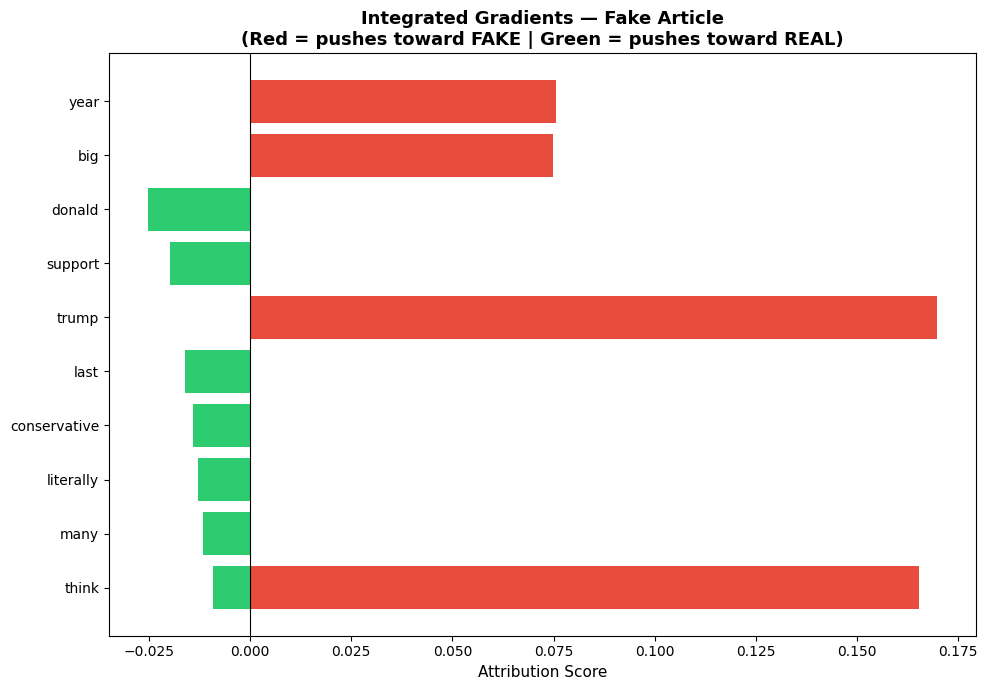

In [26]:
# Filter out subword tokens (## tokens)
word_scores_fake_clean = [(w, s) for w, s in word_scores_fake_sorted if not w.startswith("##")][:15]

words_f = [w for w, s in word_scores_fake_clean]
scores_f = [s for w, s in word_scores_fake_clean]
colors_f = ["#E74C3C" if s > 0 else "#2ECC71" for s in scores_f]

plt.figure(figsize=(10, 7))
plt.barh(words_f[::-1], scores_f[::-1], color=colors_f[::-1])
plt.title("Integrated Gradients — Fake Article\n(Red = pushes toward FAKE | Green = pushes toward REAL)",
          fontsize=13, fontweight="bold")
plt.xlabel("Attribution Score", fontsize=11)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/ig_fake_article.png", dpi=150)
plt.show()

In [27]:
real_article = samples[samples["label"] == "REAL"]["cleaned_text"].iloc[0]
real_title = samples[samples["label"] == "REAL"]["title"].iloc[0]
real_article_short = " ".join(real_article.split()[:100])

print(f"Article: {real_title[:80]}...")
print(f"Length: {len(real_article_short.split())} words")
print(f"\nRunning Integrated Gradients...")

word_scores_real = get_integrated_gradients(real_article_short, label=1)
word_scores_real_sorted = sorted(word_scores_real, key=lambda x: abs(x[1]), reverse=True)[:15]

print("\nTOP 15 WORDS — INTEGRATED GRADIENTS (REAL ARTICLE)")
print("=" * 55)
for word, score in word_scores_real_sorted:
    if not word.startswith("##"):
        direction = "→ REAL" if score > 0 else "→ FAKE"
        print(f"  {word:30} {score:+.4f}  {direction}")

Article: Majority of U.S. Senate backs disaster aid bill...
Length: 53 words

Running Integrated Gradients...

TOP 15 WORDS — INTEGRATED GRADIENTS (REAL ARTICLE)
  reuters                        +0.8963  → REAL
  washington                     +0.4088  → REAL
  u                              +0.1315  → REAL
  majority                       +0.0930  → REAL
  billion                        +0.0205  → REAL
  damage                         +0.0201  → REAL
  recover                        +0.0148  → REAL
  several                        +0.0146  → REAL
  wild                           +0.0129  → REAL
  provide                        +0.0123  → REAL
  backed                         -0.0108  → FAKE
  particular                     +0.0107  → REAL
  struggle                       +0.0099  → REAL
  would                          +0.0098  → REAL


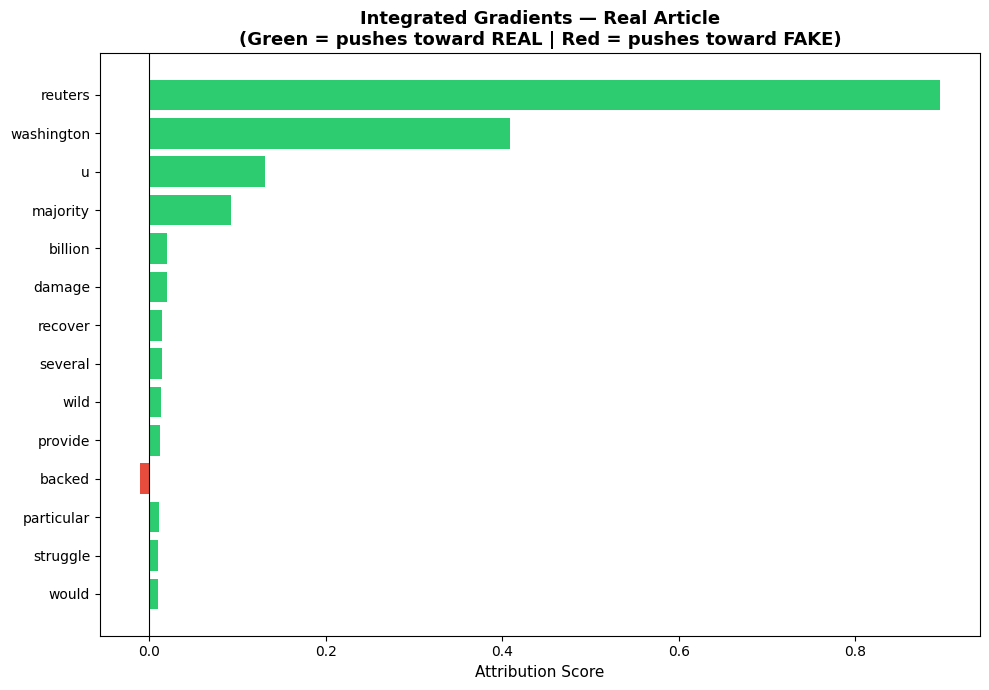

In [28]:
word_scores_real_clean = [(w, s) for w, s in word_scores_real_sorted if not w.startswith("##")][:15]

words_r = [w for w, s in word_scores_real_clean]
scores_r = [s for w, s in word_scores_real_clean]
colors_r = ["#2ECC71" if s > 0 else "#E74C3C" for s in scores_r]

plt.figure(figsize=(10, 7))
plt.barh(words_r[::-1], scores_r[::-1], color=colors_r[::-1])
plt.title("Integrated Gradients — Real Article\n(Green = pushes toward REAL | Red = pushes toward FAKE)",
          fontsize=13, fontweight="bold")
plt.xlabel("Attribution Score", fontsize=11)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/ig_real_article.png", dpi=150)
plt.show()

In [29]:
print("Running Integrated Gradients on all 10 articles...")

all_ig_results = []

for idx, row in samples.iterrows():
    article = " ".join(row["cleaned_text"].split()[:100])
    label = row["label"]
    class_idx = 0 if label == "FAKE" else 1

    word_scores = get_integrated_gradients(article, label=class_idx)
    word_scores = [(w, s) for w, s in word_scores if not w.startswith("##")]
    word_scores = sorted(word_scores, key=lambda x: abs(x[1]), reverse=True)[:15]

    all_ig_results.append({
        "label": label,
        "word_scores": word_scores
    })

    print(f"  Completed {idx + 1}/10 — {label}")

print("\nAll Integrated Gradients explanations complete")

Running Integrated Gradients on all 10 articles...
  Completed 1/10 — FAKE
  Completed 2/10 — FAKE
  Completed 3/10 — FAKE
  Completed 4/10 — FAKE
  Completed 5/10 — FAKE
  Completed 6/10 — REAL
  Completed 7/10 — REAL
  Completed 8/10 — REAL
  Completed 9/10 — REAL
  Completed 10/10 — REAL

All Integrated Gradients explanations complete


In [30]:
fake_ig_words = {}
real_ig_words = {}

for result in all_ig_results:
    if result["label"] == "FAKE":
        for word, score in result["word_scores"]:
            if score > 0:
                if word not in fake_ig_words:
                    fake_ig_words[word] = []
                fake_ig_words[word].append(score)
    else:
        for word, score in result["word_scores"]:
            if score > 0:
                if word not in real_ig_words:
                    real_ig_words[word] = []
                real_ig_words[word].append(score)

# Average and sort
fake_ig_avg = {w: np.mean(s) for w, s in fake_ig_words.items()}
real_ig_avg = {w: np.mean(s) for w, s in real_ig_words.items()}

fake_ig_sorted = sorted(fake_ig_avg.items(), key=lambda x: x[1], reverse=True)[:20]
real_ig_sorted = sorted(real_ig_avg.items(), key=lambda x: x[1], reverse=True)[:20]

print("TOP 20 FAKE INDICATORS — INTEGRATED GRADIENTS")
print("=" * 50)
for word, score in fake_ig_sorted:
    print(f"  {word:30} {score:+.4f}")

print("\nTOP 20 REAL INDICATORS — INTEGRATED GRADIENTS")
print("=" * 50)
for word, score in real_ig_sorted:
    print(f"  {word:30} {score:+.4f}")

TOP 20 FAKE INDICATORS — INTEGRATED GRADIENTS
  think                          +0.1653
  trump                          +0.0939
  inc                            +0.0839
  year                           +0.0756
  big                            +0.0748
  would                          +0.0582
  word                           +0.0544
  adam                           +0.0419
  activist                       +0.0360
  eve                            +0.0355
  information                    +0.0352
  awareness                      +0.0317
  legion                         +0.0282
  working                        +0.0279
  devastating                    +0.0254
  house                          +0.0212
  nightstand                     +0.0188
  get                            +0.0170
  everything                     +0.0166
  summer                         +0.0144

TOP 20 REAL INDICATORS — INTEGRATED GRADIENTS
  reuters                        +0.8578
  brussels                       +0.5111
  was

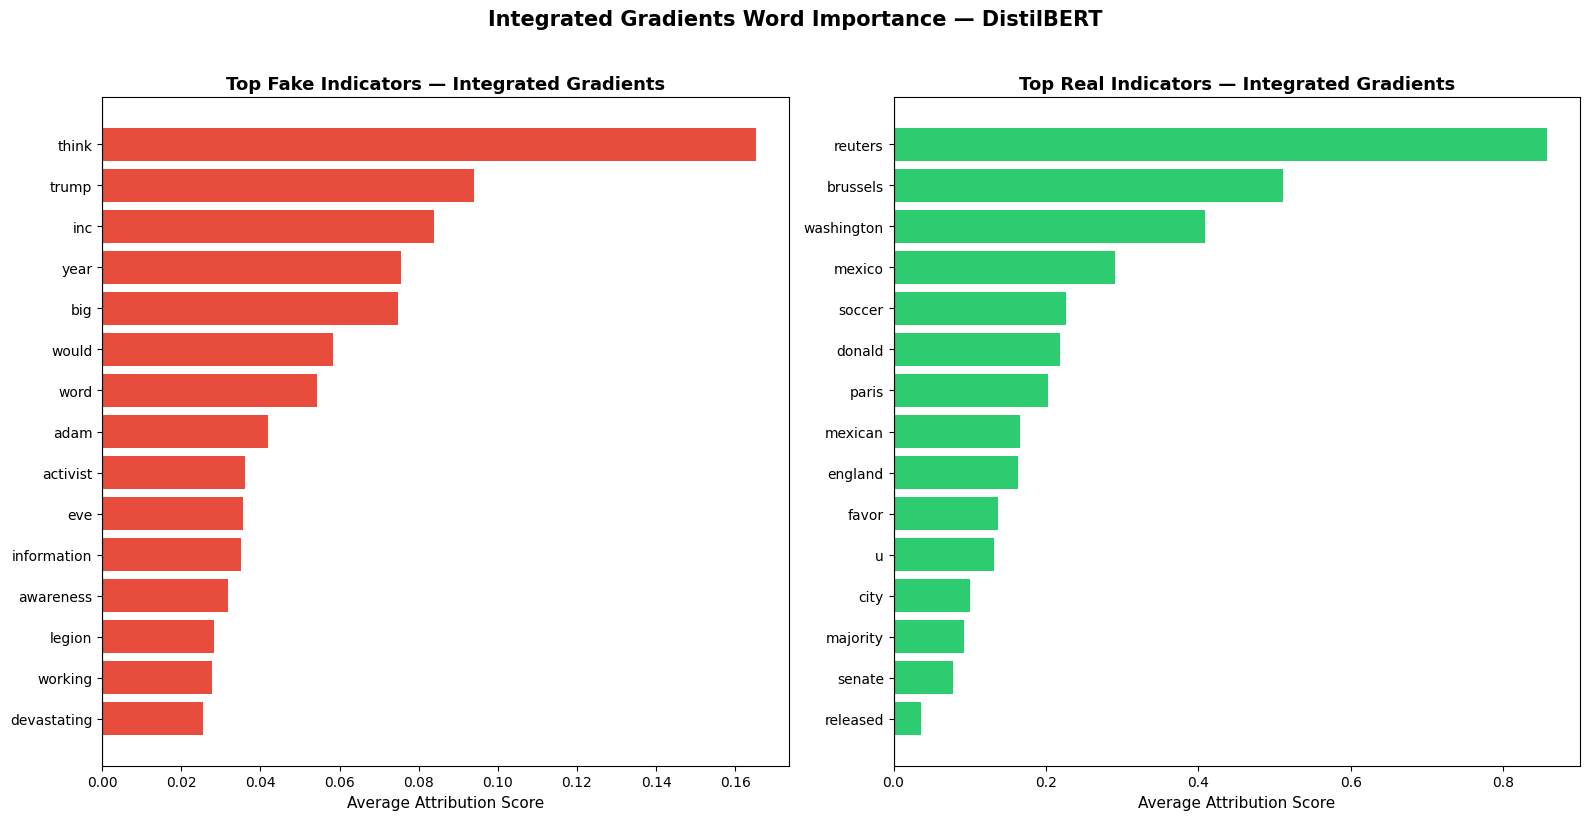

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Fake indicators
words_f = [x[0] for x in fake_ig_sorted[:15]]
scores_f = [x[1] for x in fake_ig_sorted[:15]]
ax1.barh(words_f[::-1], scores_f[::-1], color="#E74C3C")
ax1.set_title("Top Fake Indicators — Integrated Gradients",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Average Attribution Score", fontsize=11)
ax1.axvline(x=0, color="black", linewidth=0.8)

# Real indicators
words_r = [x[0] for x in real_ig_sorted[:15]]
scores_r = [x[1] for x in real_ig_sorted[:15]]
ax2.barh(words_r[::-1], scores_r[::-1], color="#2ECC71")
ax2.set_title("Top Real Indicators — Integrated Gradients",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Average Attribution Score", fontsize=11)
ax2.axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("Integrated Gradients Word Importance — DistilBERT",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/ig_combined.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [32]:
import pickle

ig_results = {
    "fake_ig_sorted": fake_ig_sorted,
    "real_ig_sorted": real_ig_sorted,
    "all_ig_results": all_ig_results
}

with open("/content/drive/MyDrive/FactLens_Group9/data/ig_results.pkl", "wb") as f:
    pickle.dump(ig_results, f)

print("Integrated Gradients results saved successfully")

Integrated Gradients results saved successfully
